# ch215 — Chain Rule

The chain rule is the calculus of composition. When one quantity depends on another, which depends on a third, the chain rule tells you how fast the first changes with respect to the third.

It is the mathematical engine behind every neural network trained by gradient descent *(forward reference: ch216 — Backpropagation Intuition)*.

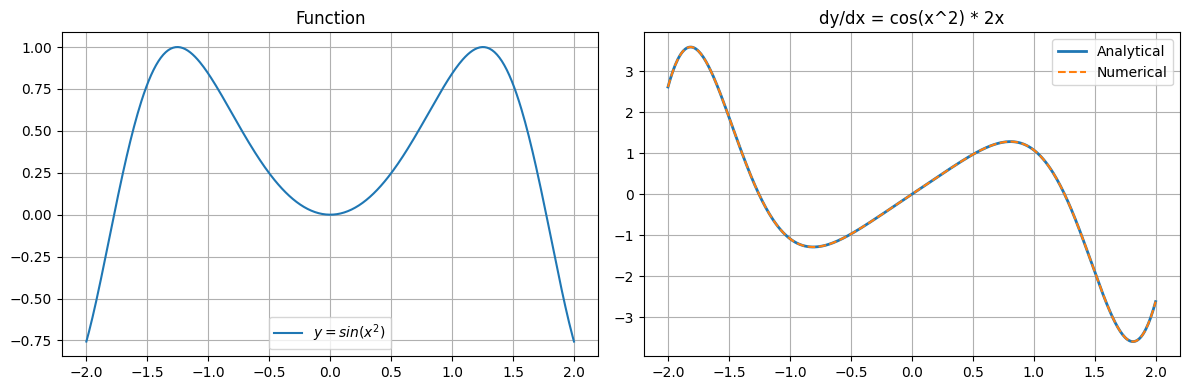

Max error between analytical and numerical: 1.01e-09


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Chain rule: if y = f(g(x)), dy/dx = f'(g(x)) * g'(x)
# Example: y = sin(x^2)
# g(x) = x^2,  g'(x) = 2x
# f(u) = sin(u), f'(u) = cos(u)
# dy/dx = cos(x^2) * 2x

x = np.linspace(-2, 2, 400)
y = np.sin(x**2)
dy_analytical = np.cos(x**2) * 2 * x

h = 1e-5
dy_numerical = (np.sin((x+h)**2) - np.sin((x-h)**2)) / (2*h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, y, label=r'$y = sin(x^2)$')
axes[0].set_title('Function'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(x, dy_analytical, label='Analytical', lw=2)
axes[1].plot(x, dy_numerical, '--', label='Numerical', lw=1.5)
axes[1].set_title('dy/dx = cos(x^2) * 2x'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.savefig('ch215_chain.png', dpi=100); plt.show()
print(f"Max error between analytical and numerical: {np.max(np.abs(dy_analytical - dy_numerical)):.2e}")

## Chain Rule as a Computation Graph

Every expression decomposes into a directed acyclic graph (DAG). The chain rule says: to get the gradient at any node, multiply all **local** derivatives along the path from that node to the output.

This is exactly what automatic differentiation *(ch208)* implements.

In [2]:
# Manual forward and backward pass for y = (x+1)^2
# This is what autodiff engines do automatically

x = 3.0

# --- Forward pass: compute values, cache intermediates ---
a = x + 1        # local op: add
b = a ** 2       # local op: square
print(f"Forward: x={x}  a={a}  b={b}")

# --- Backward pass: chain rule from output to input ---
db_db = 1.0          # seed gradient
db_da = 2 * a        # d(a^2)/da at a=4 -> 8
da_dx = 1.0          # d(x+1)/dx -> 1

dy_dx = db_db * db_da * da_dx
print(f"Chain: db/da={db_da}, da/dx={da_dx}, dy/dx={dy_dx}")

# Verify
h = 1e-7
numerical = ((x + h + 1)**2 - (x + 1)**2) / h
print(f"Numerical check: {numerical:.6f}  match={abs(dy_dx - numerical) < 1e-4}")

Forward: x=3.0  a=4.0  b=16.0
Chain: db/da=8.0, da/dx=1.0, dy/dx=8.0
Numerical check: 8.000000  match=True


## Multivariable Chain Rule

If `z = f(x(t), y(t))`, then:

```
dz/dt = (dz/dx)(dx/dt) + (dz/dy)(dy/dt)
```

This generalises to any number of intermediate variables *(partial derivatives introduced in ch210)*.

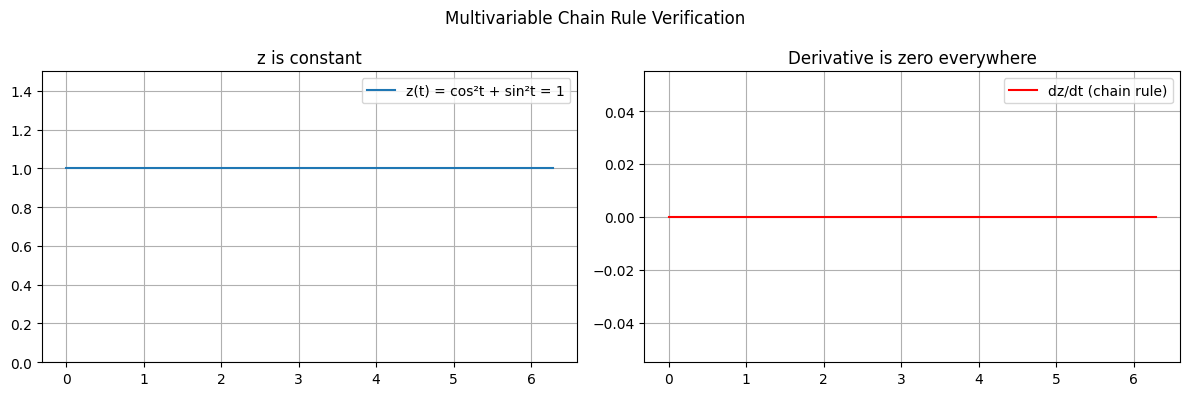

Max |dz/dt|: 0.00e+00  (numerical zero)


In [3]:
# z = x^2 + y^2, x = cos(t), y = sin(t)
# The point traces the unit circle, so z = 1 always.
# Chain rule should give dz/dt = 0 everywhere.

t = np.linspace(0, 2*np.pi, 300)
x_t = np.cos(t)
y_t = np.sin(t)
z_t = x_t**2 + y_t**2   # Should be 1.0 everywhere

dz_dt = 2*x_t*(-np.sin(t)) + 2*y_t*(np.cos(t))  # Should be 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, z_t, label='z(t) = cos²t + sin²t = 1')
axes[0].set_ylim(0, 1.5); axes[0].set_title('z is constant'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(t, dz_dt, color='red', label='dz/dt (chain rule)')
axes[1].set_title('Derivative is zero everywhere'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Multivariable Chain Rule Verification')
plt.tight_layout(); plt.savefig('ch215_multivar.png', dpi=100); plt.show()
print(f"Max |dz/dt|: {np.max(np.abs(dz_dt)):.2e}  (numerical zero)")

## Summary

| Concept | Formula |
|---|---|
| Single-variable chain rule | dy/dx = f'(g(x)) · g'(x) |
| Multivariable chain rule | dz/dt = sum (dz/dxi)(dxi/dt) |
| Computation graph view | Multiply local gradients along path |

**Forward reference:** ch216 — Backpropagation Intuition applies the chain rule systematically to every layer of a neural network, propagating gradients from output back to input.